# Prediction vs. Uplift: Causal Targeting with the Criteo Experiment

This notebook supports an article built around one decision-making question:

> **The customer most likely to respond is not necessarily the customer whose behaviour is most likely to change because of an intervention.**

We use the public **Criteo Uplift Prediction Dataset**, a randomized advertising incrementality experiment.

The analysis is intentionally narrow:

- outcome: `visit`
- treatment: randomized assignment to the advertising strategy vs. control
- CATE estimator: a **T-learner** with two nonlinear LightGBM response models
- features: all 12 anonymized pre-treatment covariates; no feature-selection stage
- development data: all observations outside the held-out evaluation population
- evaluation: one **5 million-row held-out randomized evaluation population**
- policies compared: **highest predicted visit probability** vs. **highest predicted uplift**
- reference: a fixed random 10% cohort
- ranking validation: direct randomized policy evaluation, bootstrap uncertainty, and Qini / low-capacity Qini

The notebook is illustrative and uses a public benchmark dataset; it does **not** claim production deployment or production uplift results.


## 1. Setup

The raw dataset contains roughly 14 million observations. Only the 12 anonymized pre-treatment covariates, treatment assignment, and visit outcome are required.

Update `DATA_PATH` below to point to the downloaded dataset.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.linear_model import LogisticRegression

try:
    from lightgbm import LGBMClassifier, early_stopping
except ImportError:
    %pip install -q lightgbm
    from lightgbm import LGBMClassifier, early_stopping

RANDOM_STATE = 42
FEATURES = [f"f{i}" for i in range(12)]
TREATMENT = "treatment"
TARGET = "visit"

DATA_PATH = Path(
    "criteo-research-uplift-v2.1.csv.gz"
)

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(fig, filename):
    fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")


## 2. Experiment sanity check and average treatment effect

Criteo's treatment allocation is intentionally imbalanced (roughly 85% treated / 15% control), but assignment comes from a randomized incrementality experiment.

Before estimating heterogeneous effects, establish two things:

1. observed baseline covariates are well balanced across randomized arms; and
2. treatment has a positive average effect on visits in the released benchmark population.

The covariate-balance check is a **sanity check on observed features**. Randomization, rather than the balance table itself, supplies the identification argument for exchangeability.


In [4]:
summary = pd.DataFrame({
    "rows": [len(df)],
    "treatment_share": [df[TREATMENT].mean()],
    "visit_rate": [df[TARGET].mean()],
})

display(summary.style.format({
    "rows": "{:,.0f}",
    "treatment_share": "{:.2%}",
    "visit_rate": "{:.2%}",
}))

arm_summary = (
    df.groupby(TREATMENT)[TARGET]
      .agg(visit_rate="mean", n="count")
)

display(
    arm_summary.style.format({
        "visit_rate": "{:.2%}",
        "n": "{:,.0f}",
    })
)


,rows,treatment_share,visit_rate
0,"13,979,592",85.00%,4.70%


,visit_rate,n
treatment,,
0,3.82%,"2,096,937"
1,4.85%,"11,882,655"


In [5]:
# Standardized mean differences across the randomized arms.
balance_rows = []

for feature in FEATURES:
    treated_feature = df.loc[df[TREATMENT] == 1, feature]
    control_feature = df.loc[df[TREATMENT] == 0, feature]

    pooled_sd = np.sqrt(
        (treated_feature.var(ddof=1) + control_feature.var(ddof=1)) / 2
    )

    smd = (
        treated_feature.mean() - control_feature.mean()
    ) / pooled_sd

    balance_rows.append({
        "feature": feature,
        "standardized_mean_difference": smd,
        "abs_smd": abs(smd),
    })

balance_table = (
    pd.DataFrame(balance_rows)
    .sort_values("abs_smd", ascending=False)
    .reset_index(drop=True)
)

display(
    balance_table.style
    .format({
        "standardized_mean_difference": "{:.3f}",
        "abs_smd": "{:.3f}",
    })
    .hide(axis="index")
)


feature,standardized_mean_difference,abs_smd
f3,-0.049,0.049
f6,-0.041,0.041
f5,-0.031,0.031
f9,0.024,0.024
f7,0.020,0.020
f8,-0.016,0.016
f0,-0.007,0.007
f1,0.006,0.006
f11,-0.005,0.005
f2,-0.005,0.005


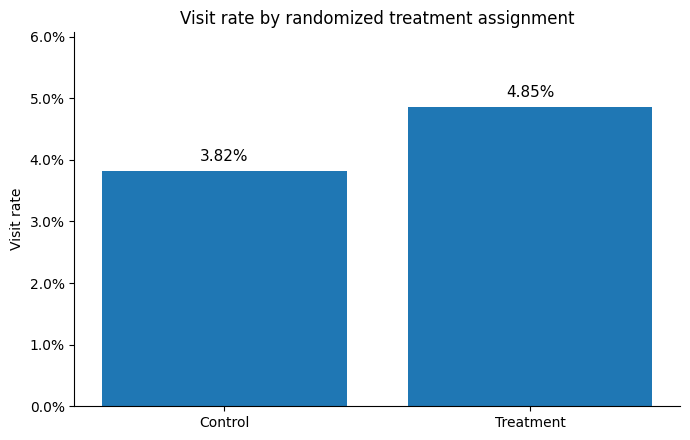

In [6]:
from matplotlib.ticker import PercentFormatter

plot_df = (
    arm_summary
    .reset_index()
    .assign(group=lambda x: x[TREATMENT].map({
        0: "Control",
        1: "Treatment",
    }))
    .sort_values(TREATMENT)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    plot_df["group"],
    plot_df["visit_rate"],
)

ax.bar_label(
    bars,
    labels=[f"{x:.2%}" for x in plot_df["visit_rate"]],
    padding=5,
    fontsize=11,
)

ax.set_ylabel("Visit rate")
ax.set_title("Visit rate by randomized treatment assignment")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, plot_df["visit_rate"].max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_figure(fig, "01_visit_rate_by_treatment.png")
plt.show()


In [7]:
treated = df.loc[df[TREATMENT] == 1, TARGET]
control = df.loc[df[TREATMENT] == 0, TARGET]

ate = treated.mean() - control.mean()

ate_se = np.sqrt(
    treated.var(ddof=1) / len(treated)
    + control.var(ddof=1) / len(control)
)

ate_ci_low = ate - 1.96 * ate_se
ate_ci_high = ate + 1.96 * ate_se

ate_summary = pd.DataFrame({
    "Treatment visit rate": [treated.mean()],
    "Control visit rate": [control.mean()],
    "ATE": [ate],
    "95% CI low": [ate_ci_low],
    "95% CI high": [ate_ci_high],
})

display(ate_summary.style.format("{:.2%}"))


,Treatment visit rate,Control visit rate,ATE,95% CI low,95% CI high
0,4.85%,3.82%,1.03%,1.01%,1.06%


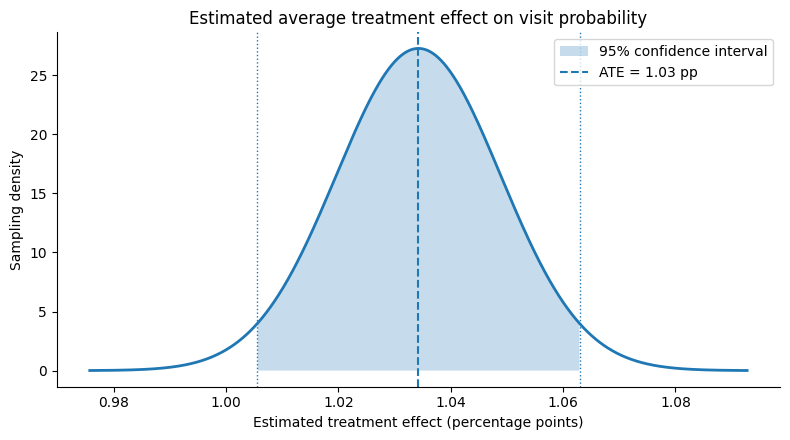

In [8]:
from scipy.stats import norm

ate_pp = ate * 100
ate_se_pp = ate_se * 100
ci_low_pp = ate_ci_low * 100
ci_high_pp = ate_ci_high * 100

x = np.linspace(
    ate_pp - 4 * ate_se_pp,
    ate_pp + 4 * ate_se_pp,
    1000,
)

density = norm.pdf(x, loc=ate_pp, scale=ate_se_pp)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(x, density, linewidth=2)
ax.fill_between(
    x,
    0,
    density,
    where=(x >= ci_low_pp) & (x <= ci_high_pp),
    alpha=0.25,
    label="95% confidence interval",
)
ax.axvline(
    ate_pp,
    linestyle="--",
    linewidth=1.5,
    label=f"ATE = {ate_pp:.2f} pp",
)
ax.axvline(ci_low_pp, linestyle=":", linewidth=1)
ax.axvline(ci_high_pp, linestyle=":", linewidth=1)

ax.set_xlabel("Estimated treatment effect (percentage points)")
ax.set_ylabel("Sampling density")
ax.set_title("Estimated average treatment effect on visit probability")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

plt.tight_layout()
save_figure(fig, "02_ate_sampling_distribution.png")
plt.show()


The ATE answers **“does treatment increase visits on average?”** It does not answer the targeting question: **“which users are most likely to change behaviour because of treatment?”**

The average treatment effect is:

$$
\mathrm{ATE} = \mathbb{E}\left[Y(1)-Y(0)\right]
$$

The targeting question instead concerns the conditional average treatment effect:

$$
\tau(x) = \mathbb{E}\left[Y(1)-Y(0) \mid X=x\right]
$$

The rest of the notebook estimates a ranking based on this heterogeneous effect and then evaluates that ranking using outcomes from an untouched randomized population.


## 3. Create one held-out evaluation population

We reserve **5 million observations** as a single held-out evaluation population, stratified by randomized treatment assignment.

The remaining observations form the development population. We do **not** artificially balance the treatment and control arms: every remaining treated observation is available to the treatment-response model, and every remaining control observation is available to the control-response model.

Within each arm, development data are split into fitting, early-stopping, probability-calibration, and diagnostic subsets. The `visit` outcome is never rebalanced.


In [9]:
EVAL_SIZE = 5_000_000

development_pool, final_eval = train_test_split(
    df,
    test_size=EVAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TREATMENT],
)

# Treatment assignment determines which response model a row develops.
# It is NOT passed into LightGBM as a predictor.
train_treated = development_pool.loc[
    development_pool[TREATMENT] == 1
].copy()

train_control = development_pool.loc[
    development_pool[TREATMENT] == 0
].copy()

print(f"Total rows: {len(df):,}")
print(f"Development rows: {len(development_pool):,}")
print(f"Held-out evaluation rows: {len(final_eval):,}")
print()
print(f"Treatment-arm development rows: {len(train_treated):,}")
print(f"Control-arm development rows: {len(train_control):,}")
print()
print("Evaluation treatment share:", f"{final_eval[TREATMENT].mean():.2%}")
print("Development treatment share:", f"{development_pool[TREATMENT].mean():.2%}")


Total rows: 13,979,592
Development rows: 8,979,592
Held-out evaluation rows: 5,000,000

Treatment-arm development rows: 7,632,654
Control-arm development rows: 1,346,938

Evaluation treatment share: 85.00%
Development treatment share: 85.00%


## 4. Fit the final T-learner

A **T-learner** estimates the treated and untreated response surfaces separately:

$$
\hat{\mu}_1(x) = \widehat{\mathbb{E}}\left[Y \mid T=1, X=x\right]
$$

$$
\hat{\mu}_0(x) = \widehat{\mathbb{E}}\left[Y \mid T=0, X=x\right]
$$

and estimates conditional uplift as:

$$
\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)
$$

Because `visit` is binary, each response surface can also be interpreted as an estimated visit probability.

The treatment variable is **not** passed into either LightGBM model as a feature. Instead, randomized treatment assignment determines which response model each development observation belongs to:

- `T = 1`: the 12 pre-treatment features predict `visit` in the treatment-response model;
- `T = 0`: the same 12 pre-treatment features predict `visit` in the control-response model.

At scoring time, the same customer feature vector is passed through **both** fitted models. Their calibrated probability difference is the customer's estimated uplift score.

All 12 anonymized pre-treatment covariates are retained. Gradient-boosted trees capture nonlinear relationships and interactions without a manual feature-selection stage.

Each arm-specific LightGBM model uses separate fitting, early-stopping, calibration, and diagnostic subsets. Platt calibration is applied independently to the two response models before their probabilities are subtracted.


In [10]:
# Create independent fit, early-stopping, calibration, and diagnostic subsets within each treatment arm.
def make_arm_splits(arm_df, seed):
    core, calibration_and_diagnostic = train_test_split(
        arm_df,
        test_size=0.15,
        random_state=seed,
        stratify=arm_df[TARGET],
    )

    calibration, diagnostic = train_test_split(
        calibration_and_diagnostic,
        test_size=0.50,
        random_state=seed + 50,
        stratify=calibration_and_diagnostic[TARGET],
    )

    fit, early_stop = train_test_split(
        core,
        test_size=(0.10 / 0.85),  # 75/10/7.5/7.5 overall
        random_state=seed + 100,
        stratify=core[TARGET],
    )

    return {
        "fit": fit,
        "early_stop": early_stop,
        "calibration": calibration,
        "diagnostic": diagnostic,
    }


treated_splits = make_arm_splits(train_treated, RANDOM_STATE)
control_splits = make_arm_splits(train_control, RANDOM_STATE + 1)

print(
    "Treated split sizes:",
    {k: len(v) for k, v in treated_splits.items()},
)
print(
    "Control split sizes:",
    {k: len(v) for k, v in control_splits.items()},
)

Treated split sizes: {'fit': 5724489, 'early_stop': 763266, 'calibration': 572449, 'diagnostic': 572450}
Control split sizes: {'fit': 1010203, 'early_stop': 134694, 'calibration': 101020, 'diagnostic': 101021}


In [11]:
# Locked final LightGBM specification used for both arms.
MODEL_PARAMS = {
    "n_estimators": 1200,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 500,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}


def _logit(p):
    p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_arm_model(splits, seed):
    model = LGBMClassifier(
        objective="binary",
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
        **MODEL_PARAMS,
    )

    model.fit(
        splits["fit"][FEATURES],
        splits["fit"][TARGET],
        eval_set=[(
            splits["early_stop"][FEATURES],
            splits["early_stop"][TARGET],
        )],
        eval_metric="binary_logloss",
        callbacks=[early_stopping(stopping_rounds=75, verbose=False)],
    )

    # Independent probability calibration on a third development subset.
    p_cal_raw = model.predict_proba(
        splits["calibration"][FEATURES]
    )[:, 1]

    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=500,
    )
    calibrator.fit(
        _logit(p_cal_raw).reshape(-1, 1),
        splits["calibration"][TARGET],
    )

    return {
        "model": model,
        "calibrator": calibrator,
    }


def predict_arm(bundle, frame, calibrated=True):
    p_raw = bundle["model"].predict_proba(frame[FEATURES])[:, 1]

    if not calibrated:
        return p_raw

    return bundle["calibrator"].predict_proba(
        _logit(p_raw).reshape(-1, 1)
    )[:, 1]


def score_t_learner(bundle, frame):
    scored = frame[[TREATMENT, TARGET]].copy()
    scored["mu_1"] = predict_arm(bundle["treated"], frame)
    scored["mu_0"] = predict_arm(bundle["control"], frame)
    scored["uplift"] = scored["mu_1"] - scored["mu_0"]
    return scored


t_learner = {
    "treated": fit_arm_model(treated_splits, RANDOM_STATE),
    "control": fit_arm_model(control_splits, RANDOM_STATE + 1),
}


## 5. Evaluation helpers

In [12]:
def evaluate_policy_group(group):
    treated_group = group.loc[group[TREATMENT] == 1, TARGET]
    control_group = group.loc[group[TREATMENT] == 0, TARGET]

    treated_rate = treated_group.mean()
    control_rate = control_group.mean()
    uplift = treated_rate - control_rate

    se = np.sqrt(
        treated_group.var(ddof=1) / len(treated_group)
        + control_group.var(ddof=1) / len(control_group)
    )

    return {
        "n": int(len(group)),
        "treated_n": int(len(treated_group)),
        "control_n": int(len(control_group)),
        "treated_rate": float(treated_rate),
        "control_rate": float(control_rate),
        "uplift": float(uplift),
        "ci_low": float(uplift - 1.96 * se),
        "ci_high": float(uplift + 1.96 * se),
        "expected_incremental_visits": float(uplift * len(group)),
    }


def qini_curve(df, score_col, n_points=201):
    ranked = (
        df[[TREATMENT, TARGET, score_col]]
        .sort_values(score_col, ascending=False)
        .reset_index(drop=True)
    )

    treatment = ranked[TREATMENT].to_numpy()
    outcome = ranked[TARGET].to_numpy()

    cum_treated = np.cumsum(treatment)
    cum_control = np.cumsum(1 - treatment)
    cum_y_treated = np.cumsum(outcome * treatment)
    cum_y_control = np.cumsum(outcome * (1 - treatment))

    n = len(ranked)
    positions = np.unique(np.linspace(1, n, n_points, dtype=int)) - 1

    n_t = cum_treated[positions]
    n_c = cum_control[positions]
    y_t = cum_y_treated[positions]
    y_c = cum_y_control[positions]

    valid = (n_t > 0) & (n_c > 0)
    positions = positions[valid]
    n_t = n_t[valid]
    n_c = n_c[valid]
    y_t = y_t[valid]
    y_c = y_c[valid]

    gain = y_t - y_c * (n_t / n_c)

    return pd.concat(
        [
            pd.DataFrame({
                "fraction_targeted": [0.0],
                "qini_gain": [0.0],
            }),
            pd.DataFrame({
                "fraction_targeted": (positions + 1) / n,
                "qini_gain": gain,
            }),
        ],
        ignore_index=True,
    )


def qini_area_above_random(curve, max_fraction=1.0):
    clean = curve.dropna(subset=["qini_gain"]).copy()
    x_full = clean["fraction_targeted"].to_numpy()
    y_full = clean["qini_gain"].to_numpy()

    final_gain = y_full[-1]

    # Interpolate the requested cutoff so each ranking is integrated
    # over exactly the same targeting range.
    x = x_full[x_full <= max_fraction]
    y = y_full[x_full <= max_fraction]

    if len(x) == 0 or x[-1] < max_fraction:
        y_cut = np.interp(max_fraction, x_full, y_full)
        x = np.append(x, max_fraction)
        y = np.append(y, y_cut)

    random_gain = x * final_gain
    integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrate(y - random_gain, x))


## 6. Response-model diagnostics

Before causal policy evaluation, inspect ordinary response-model performance on arm-specific diagnostic subsets that were not used for fitting, early stopping, or calibration.

These are **not causal evaluation metrics**. Strong response prediction does not guarantee strong treatment-effect ranking; the randomized policy evaluation below is what ultimately matters.


In [13]:
def arm_diagnostics(bundle, splits):
    y = splits["diagnostic"][TARGET].to_numpy()
    p_raw = predict_arm(bundle, splits["diagnostic"], calibrated=False)
    p_cal = predict_arm(bundle, splits["diagnostic"], calibrated=True)

    return {
        "AUC": roc_auc_score(y, p_cal),
        "raw_log_loss": log_loss(y, p_raw),
        "calibrated_log_loss": log_loss(y, p_cal),
        "raw_brier": brier_score_loss(y, p_raw),
        "calibrated_brier": brier_score_loss(y, p_cal),
        "observed_rate": y.mean(),
        "mean_raw_probability": p_raw.mean(),
        "mean_calibrated_probability": p_cal.mean(),
    }


response_diagnostics = pd.DataFrame({
    "Treatment response model": arm_diagnostics(
        t_learner["treated"],
        treated_splits,
    ),
    "Control response model": arm_diagnostics(
        t_learner["control"],
        control_splits,
    ),
}).T

display(
    response_diagnostics.style.format({
        "AUC": "{:.4f}",
        "raw_log_loss": "{:.4f}",
        "calibrated_log_loss": "{:.4f}",
        "raw_brier": "{:.4f}",
        "calibrated_brier": "{:.4f}",
        "observed_rate": "{:.2%}",
        "mean_raw_probability": "{:.2%}",
        "mean_calibrated_probability": "{:.2%}",
    })
)

,AUC,raw_log_loss,calibrated_log_loss,raw_brier,calibrated_brier,observed_rate,mean_raw_probability,mean_calibrated_probability
Treatment response model,0.9474,0.1045,0.1045,0.0303,0.0303,4.86%,4.86%,4.85%
Control response model,0.9496,0.0887,0.0887,0.0254,0.0254,3.82%,3.80%,3.79%


## 7. Score the held-out evaluation population

Only after model development is complete do we score the 5 million-row held-out evaluation population. For every user, the same pre-treatment feature vector is passed through both fitted response models.

This produces the two policies compared throughout the article:

1. **Predicted-visit ranking:** rank by $\hat{\mu}_1(x)$, the probability of visiting if treated.
2. **Predicted-uplift ranking:** rank by $\hat{\tau}(x)=\hat{\mu}_1(x)-\hat{\mu}_0(x)$, the estimated change in visit probability under treatment.

The held-out outcomes are used to evaluate these rankings, not to fit or calibrate the models.


In [14]:
results = score_t_learner(t_learner, final_eval)

# Probability-calibration sanity check on the untouched final population.
observed_treated_rate = results.loc[results[TREATMENT] == 1, TARGET].mean()
observed_control_rate = results.loc[results[TREATMENT] == 0, TARGET].mean()

mean_mu1_treated = results.loc[results[TREATMENT] == 1, "mu_1"].mean()
mean_mu0_control = results.loc[results[TREATMENT] == 0, "mu_0"].mean()

predicted_ate = results["uplift"].mean()
observed_final_ate = observed_treated_rate - observed_control_rate

final_calibration = pd.DataFrame({
    "observed_rate": [observed_treated_rate, observed_control_rate],
    "mean_predicted_probability": [mean_mu1_treated, mean_mu0_control],
}, index=["Treatment arm", "Control arm"])

final_calibration["gap"] = (
    final_calibration["mean_predicted_probability"]
    - final_calibration["observed_rate"]
)

display(final_calibration.style.format("{:.2%}"))
print(f"Mean predicted treatment effect: {predicted_ate * 100:.2f}pp")
print(f"Observed final-holdout ATE: {observed_final_ate * 100:.2f}pp")

,observed_rate,mean_predicted_probability,gap
Treatment arm,4.85%,4.85%,0.00%
Control arm,3.83%,3.79%,-0.04%


Mean predicted treatment effect: 0.76pp
Observed final-holdout ATE: 1.02pp


## 8. Evaluate targeting policies on randomized final outcomes

Once a cohort has been selected, evaluate it using the **actual randomized treatment assignment and observed visit outcome** in the held-out evaluation population.

For a selected cohort $S$:

$$
\hat{\tau}_S = \bar{Y}_{T=1,S} - \bar{Y}_{T=0,S}
$$

We compare the two model-based targeting policies with a **fixed random 10% reference cohort** drawn from the same final evaluation population. The random cohort is included for context only: the primary statistical comparison remains **predicted uplift vs. predicted visit**.

The model creates the ranking; the randomized experiment **grades the ranking**.


In [15]:
TARGET_FRAC = 0.10
RANDOM_COHORT_SEED = 20260920
n_target = int(len(results) * TARGET_FRAC)

groups_10 = {
    "Random 10% reference": results.sample(
        n=n_target,
        random_state=RANDOM_COHORT_SEED,
    ),
    "Highest predicted visit": results.nlargest(n_target, "mu_1"),
    "Highest predicted uplift": results.nlargest(n_target, "uplift"),
}

comparison_10 = pd.DataFrame({
    name: evaluate_policy_group(group)
    for name, group in groups_10.items()
}).T

comparison_columns = [
    "n",
    "treated_n",
    "control_n",
    "treated_rate",
    "control_rate",
    "uplift",
    "ci_low",
    "ci_high",
    "expected_incremental_visits",
]

display(
    comparison_10[comparison_columns].style.format({
        "n": "{:,.0f}",
        "treated_n": "{:,.0f}",
        "control_n": "{:,.0f}",
        "treated_rate": "{:.2%}",
        "control_rate": "{:.2%}",
        "uplift": "{:.2%}",
        "ci_low": "{:.2%}",
        "ci_high": "{:.2%}",
        "expected_incremental_visits": "{:,.0f}",
    })
)

random_idx = groups_10["Random 10% reference"].index
visit_idx = groups_10["Highest predicted visit"].index
uplift_idx = groups_10["Highest predicted uplift"].index

top10_overlap = len(visit_idx.intersection(uplift_idx)) / n_target

random_uplift = comparison_10.loc["Random 10% reference", "uplift"]
visit_uplift = comparison_10.loc["Highest predicted visit", "uplift"]
causal_uplift = comparison_10.loc["Highest predicted uplift", "uplift"]
policy_advantage = causal_uplift - visit_uplift
relative_improvement = policy_advantage / visit_uplift

# print(f"Random 10% reference uplift: {random_uplift * 100:.2f}pp")
# print(f"Predicted-visit policy uplift: {visit_uplift * 100:.2f}pp")
# print(f"Predicted-uplift policy uplift: {causal_uplift * 100:.2f}pp")
# print(f"Absolute policy advantage: {policy_advantage * 100:.2f}pp")
print(f"Relative improvement: {relative_improvement:.1%}")
print(f"Top-10% overlap between model-based rankings: {top10_overlap:.1%}")


,n,treated_n,control_n,treated_rate,control_rate,uplift,ci_low,ci_high,expected_incremental_visits
Random 10% reference,"500,000","425,344","74,656",4.82%,3.81%,1.01%,0.86%,1.16%,"5,055"
Highest predicted visit,"500,000","430,830","69,170",37.41%,32.28%,5.14%,4.76%,5.51%,"25,686"
Highest predicted uplift,"500,000","432,645","67,355",29.11%,23.22%,5.88%,5.54%,6.23%,"29,419"


Relative improvement: 14.5%
Top-10% overlap between model-based rankings: 67.5%


## 9. Article visual — baseline propensity vs. incremental treatment effect

This figure makes the article's central distinction visible. The random cohort provides a population-like reference; the two targeted cohorts show how response-based and uplift-based ranking concentrate very different combinations of baseline propensity and incremental treatment effect.


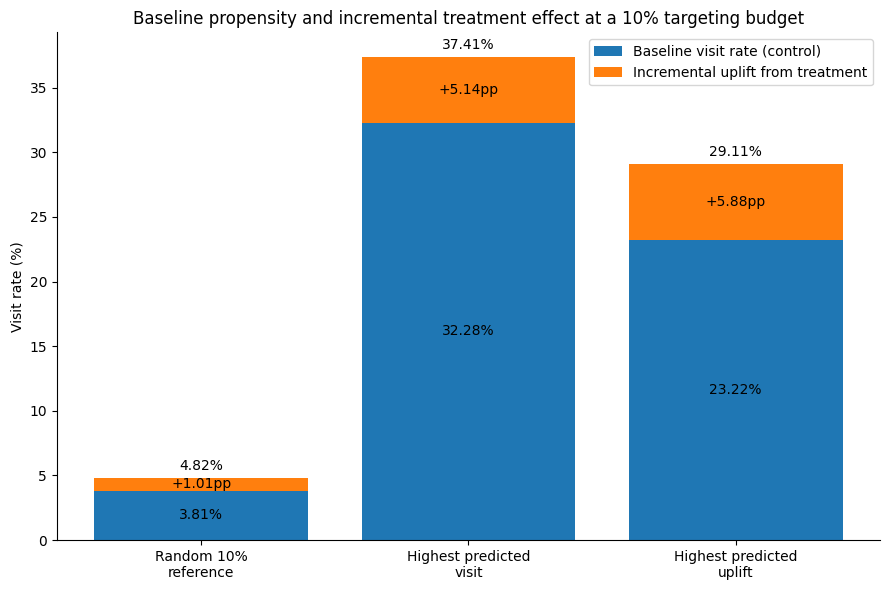

In [16]:
plot_order = [
    "Random 10% reference",
    "Highest predicted visit",
    "Highest predicted uplift",
]

stack_df = comparison_10.loc[plot_order].copy()
stack_df["baseline_pp"] = stack_df["control_rate"] * 100
stack_df["uplift_pp"] = stack_df["uplift"] * 100

labels = [
    "Random 10%\nreference",
    "Highest predicted\nvisit",
    "Highest predicted\nuplift",
]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(x, stack_df["baseline_pp"], label="Baseline visit rate (control)")
ax.bar(
    x,
    stack_df["uplift_pp"],
    bottom=stack_df["baseline_pp"],
    label="Incremental uplift from treatment",
)

for i, row in enumerate(stack_df.itertuples()):
    total = row.baseline_pp + row.uplift_pp
    ax.text(i, total + 0.6, f"{total:.2f}%", ha="center")
    ax.text(
        i,
        row.baseline_pp / 2,
        f"{row.baseline_pp:.2f}%",
        ha="center",
        va="center",
    )
    ax.text(
        i,
        row.baseline_pp + row.uplift_pp / 2,
        f"+{row.uplift_pp:.2f}pp",
        ha="center",
        va="center",
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Visit rate (%)")
ax.set_title("Baseline propensity and incremental treatment effect at a 10% targeting budget")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_figure(fig, "03_baseline_plus_uplift_10pct.png")
plt.show()


## 10. Article visual — direct uplift comparison

The horizontal error bars show normal-approximation 95% confidence intervals for the observed treatment-control difference within each cohort. The random cohort is a reference; the inferential comparison of interest remains predicted uplift vs. predicted visit.


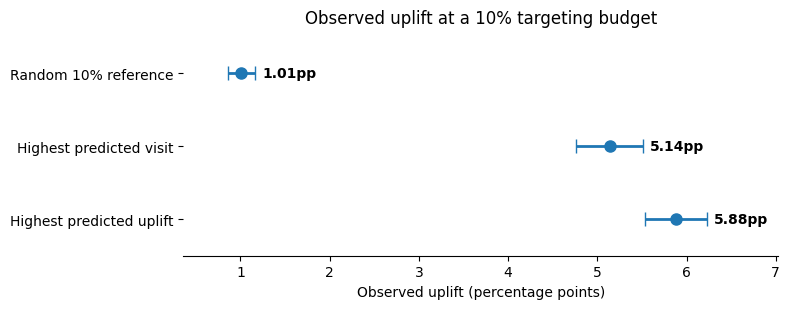

In [17]:
plot_order = [
    "Random 10% reference",
    "Highest predicted visit",
    "Highest predicted uplift",
]

uplift_plot = comparison_10.loc[plot_order].copy()
uplift_plot["uplift_pp"] = uplift_plot["uplift"] * 100
uplift_plot["ci_low_pp"] = uplift_plot["ci_low"] * 100
uplift_plot["ci_high_pp"] = uplift_plot["ci_high"] * 100

labels = [
    "Random 10% reference",
    "Highest predicted visit",
    "Highest predicted uplift",
]
y = np.arange(len(labels))
estimate = uplift_plot["uplift_pp"].to_numpy()

xerr = np.vstack([
    estimate - uplift_plot["ci_low_pp"].to_numpy(),
    uplift_plot["ci_high_pp"].to_numpy() - estimate,
])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(
    estimate,
    y,
    xerr=xerr,
    fmt="o",
    markersize=8,
    capsize=5,
    linewidth=2,
)

for i, row in enumerate(uplift_plot.itertuples()):
    ax.text(
        row.ci_high_pp + 0.08,
        y[i],
        f"{row.uplift_pp:.2f}pp",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_ylim(-0.5, len(labels) - 0.5)
ax.invert_yaxis()
ax.set_xlim(
    max(0, uplift_plot["ci_low_pp"].min() - 0.5),
    uplift_plot["ci_high_pp"].max() + 0.8,
)
ax.set_xlabel("Observed uplift (percentage points)")
ax.set_title("Observed uplift at a 10% targeting budget", pad=10)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
save_figure(fig, "04_direct_uplift_10pct.png")
plt.show()


## 11. Bootstrap the direct policy advantage

The two model-selected cohorts overlap, so comparing their individual confidence intervals is not a formal test of the difference between policies.

We therefore bootstrap the **predicted-uplift minus predicted-visit** policy difference on the final held-out evaluation population, preserving cohort overlap. The random 10% cohort is not part of this hypothesis comparison; it is included only as a descriptive reference in the table and article visuals.

This bootstrap is conditional on the locked T-learner; it does not refit the LightGBM models in every bootstrap draw.


Observed policy advantage: 0.75pp
95% bootstrap CI: [0.48, 1.02]pp
Bootstrap draws with advantage > 0: 100.00%


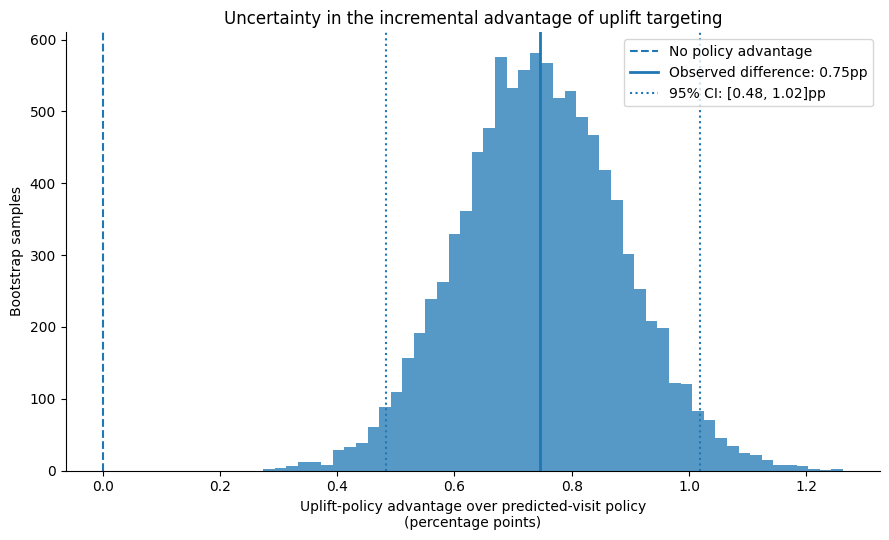

In [18]:
N_BOOTSTRAPS = 10_000
BOOTSTRAP_SEED = 42

bootstrap_df = results[[TREATMENT, TARGET]].copy()
bootstrap_df["visit_policy"] = bootstrap_df.index.isin(visit_idx).astype("int8")
bootstrap_df["uplift_policy"] = bootstrap_df.index.isin(uplift_idx).astype("int8")

cell_index = pd.MultiIndex.from_product(
    [
        [0, 1],
        [0, 1],
        [0, 1],
        [0, 1],
    ],
    names=["visit_policy", "uplift_policy", TREATMENT, TARGET],
)

cell_counts = (
    bootstrap_df
    .groupby(["visit_policy", "uplift_policy", TREATMENT, TARGET])
    .size()
    .reindex(cell_index, fill_value=0)
    .reset_index(name="count")
)

counts = cell_counts["count"].to_numpy()
probs = counts / counts.sum()

rng = np.random.default_rng(BOOTSTRAP_SEED)
boot_counts = rng.multinomial(
    n=counts.sum(),
    pvals=probs,
    size=N_BOOTSTRAPS,
)

cell_visit = cell_counts["visit_policy"].to_numpy() == 1
cell_uplift = cell_counts["uplift_policy"].to_numpy() == 1
cell_treated = cell_counts[TREATMENT].to_numpy() == 1
cell_positive = cell_counts[TARGET].to_numpy() == 1


def bootstrap_policy_uplift(policy_mask):
    treated_mask = policy_mask & cell_treated
    control_mask = policy_mask & ~cell_treated

    n_t = boot_counts[:, treated_mask].sum(axis=1)
    n_c = boot_counts[:, control_mask].sum(axis=1)
    y_t = boot_counts[:, treated_mask & cell_positive].sum(axis=1)
    y_c = boot_counts[:, control_mask & cell_positive].sum(axis=1)

    return (y_t / n_t) - (y_c / n_c)


boot_visit = bootstrap_policy_uplift(cell_visit)
boot_uplift = bootstrap_policy_uplift(cell_uplift)
boot_advantage = boot_uplift - boot_visit

observed_advantage_pp = policy_advantage * 100
ci_low_pp, ci_high_pp = np.percentile(boot_advantage * 100, [2.5, 97.5])
prob_positive = np.mean(boot_advantage > 0)

print(f"Observed policy advantage: {observed_advantage_pp:.2f}pp")
print(f"95% bootstrap CI: [{ci_low_pp:.2f}, {ci_high_pp:.2f}]pp")
print(f"Bootstrap draws with advantage > 0: {prob_positive:.2%}")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(boot_advantage * 100, bins=50, alpha=0.75)
ax.axvline(0, linestyle="--", linewidth=1.5, label="No policy advantage")
ax.axvline(observed_advantage_pp, linewidth=2, label=f"Observed difference: {observed_advantage_pp:.2f}pp")
ax.axvline(ci_low_pp, linestyle=":", linewidth=1.5)
ax.axvline(ci_high_pp, linestyle=":", linewidth=1.5, label=f"95% CI: [{ci_low_pp:.2f}, {ci_high_pp:.2f}]pp")

ax.set_xlabel("Uplift-policy advantage over predicted-visit policy\n(percentage points)")
ax.set_ylabel("Bootstrap samples")
ax.set_title("Uncertainty in the incremental advantage of uplift targeting")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_figure(fig, "05_bootstrap_policy_advantage_10pct.png")
plt.show()

## 12. Qini validation across targeting depths

A 10% targeting budget is only one operating point. Qini curves ask how quickly **cumulative incremental response** is captured as progressively more of the ranked population is targeted.

Because the article is explicitly about constrained capacity, report both:

- **full-population Qini area above random**, and
- **partial Qini area above random over the first 20% of the population**.

The partial metric is the more decision-aligned diagnostic for this article.

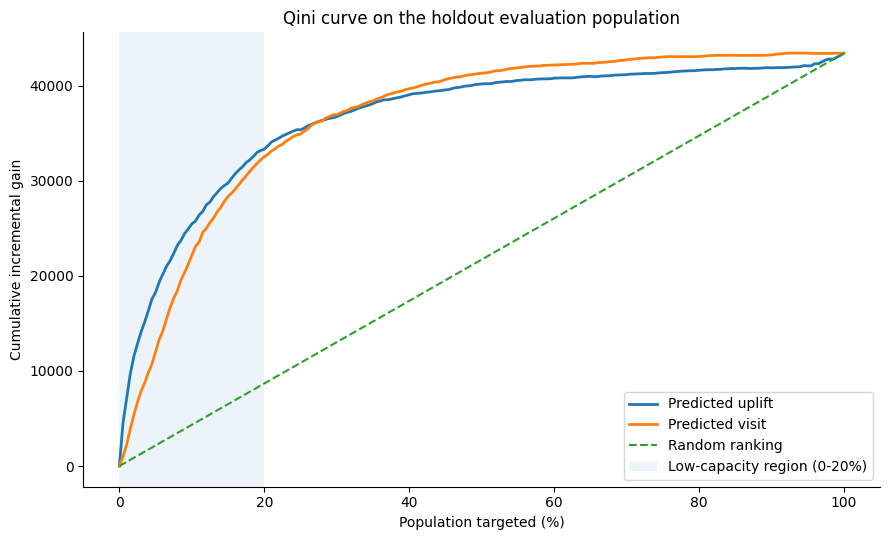

Full Qini area above random - uplift ranking: 14,964
Full Qini area above random - visit ranking: 15,043

0-20% partial Qini area - uplift ranking: 3,811
0-20% partial Qini area - visit ranking: 3,111
Relative low-capacity Qini improvement: 22.5%


In [19]:
qini_uplift = qini_curve(results, "uplift")
qini_visit = qini_curve(results, "mu_1")

qini_uplift_plot = qini_uplift.dropna(subset=["qini_gain"]).reset_index(drop=True)
qini_visit_plot = qini_visit.dropna(subset=["qini_gain"]).reset_index(drop=True)

final_gain = qini_uplift_plot["qini_gain"].iloc[-1]
random_baseline = qini_uplift_plot["fraction_targeted"] * final_gain

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    qini_uplift_plot["fraction_targeted"] * 100,
    qini_uplift_plot["qini_gain"],
    linewidth=2,
    label="Predicted uplift",
)
ax.plot(
    qini_visit_plot["fraction_targeted"] * 100,
    qini_visit_plot["qini_gain"],
    linewidth=2,
    label="Predicted visit",
)
ax.plot(
    qini_uplift_plot["fraction_targeted"] * 100,
    random_baseline,
    linestyle="--",
    linewidth=1.5,
    label="Random ranking",
)

ax.axvspan(0, 20, alpha=0.08, label="Low-capacity region (0-20%)")
ax.set_xlabel("Population targeted (%)")
ax.set_ylabel("Cumulative incremental gain")
ax.set_title("Qini curve on the holdout evaluation population")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_figure(fig, "06_qini_curve.png")
plt.show()

uplift_qini_full = qini_area_above_random(qini_uplift, 1.00)
visit_qini_full = qini_area_above_random(qini_visit, 1.00)
uplift_qini_20 = qini_area_above_random(qini_uplift, 0.20)
visit_qini_20 = qini_area_above_random(qini_visit, 0.20)

print(f"Full Qini area above random - uplift ranking: {uplift_qini_full:,.0f}")
print(f"Full Qini area above random - visit ranking: {visit_qini_full:,.0f}")
print()
print(f"0-20% partial Qini area - uplift ranking: {uplift_qini_20:,.0f}")
print(f"0-20% partial Qini area - visit ranking: {visit_qini_20:,.0f}")
if visit_qini_20 > 0:
    print(
        "Relative low-capacity Qini improvement: "
        f"{(uplift_qini_20 / visit_qini_20 - 1):.1%}"
    )

## 13. Optional diagnostic — observed uplift at selected targeting capacities

The Qini curve is the main ranking diagnostic. This table is retained as a transparent sanity check on the average observed treatment effect among the top-ranked 5%, 10%, 15%, 20%, and 25% under each intelligent targeting policy.

In [20]:
TARGET_FRACTIONS = np.arange(0.05, 0.30, 0.05)
policy_rows = []

for frac in TARGET_FRACTIONS:
    n = int(len(results) * frac)

    groups = {
        "Predicted visit": results.nlargest(n, "mu_1"),
        "Predicted uplift": results.nlargest(n, "uplift"),
    }

    for strategy, group in groups.items():
        policy_rows.append({
            "target_fraction": frac,
            "strategy": strategy,
            **evaluate_policy_group(group),
        })

policy_results = pd.DataFrame(policy_rows)
policy_table = policy_results.pivot(
    index="target_fraction",
    columns="strategy",
    values="uplift",
)

display(policy_table.style.format("{:.2%}"))

strategy,Predicted uplift,Predicted visit
target_fraction,,
0.050000,8.34%,5.56%
0.100000,5.88%,5.14%
0.150000,4.61%,4.40%
0.200000,3.88%,3.80%
0.250000,3.31%,3.26%


## 14. Final-run headline summary

This cell derives the article-level numbers directly from the current final run.


In [21]:
print("Final T-learner specification: all 12 pre-treatment features")
print(f"Development population: {len(development_pool):,} rows")
print(f"Held-out evaluation population: {len(final_eval):,} rows")
print()
print(f"Held-out ATE: {observed_final_ate * 100:.2f}pp")
print(f"Mean predicted treatment effect: {predicted_ate * 100:.2f}pp")
print()
print("At a 10% targeting budget:")
print(f"  Random 10% reference uplift: {random_uplift * 100:.2f}pp")
print(f"  Predicted-visit uplift: {visit_uplift * 100:.2f}pp")
print(f"  Predicted-uplift uplift: {causal_uplift * 100:.2f}pp")
print(f"  Absolute policy advantage: {policy_advantage * 100:.2f}pp")
print(f"  Relative policy improvement: {relative_improvement:.1%}")
print(f"  Top-10% audience overlap: {top10_overlap:.1%}")
print(f"  Bootstrap 95% CI for policy advantage: [{ci_low_pp:.2f}, {ci_high_pp:.2f}]pp")
print()
print("Qini validation:")
print(f"  Full area - uplift ranking: {uplift_qini_full:,.0f}")
print(f"  Full area - visit ranking: {visit_qini_full:,.0f}")
print(f"  0-20% partial area - uplift ranking: {uplift_qini_20:,.0f}")
print(f"  0-20% partial area - visit ranking: {visit_qini_20:,.0f}")
if visit_qini_20 > 0:
    print(
        f"  Relative low-capacity Qini improvement: "
        f"{(uplift_qini_20 / visit_qini_20 - 1):.1%}"
    )


Final T-learner specification: all 12 pre-treatment features
Development population: 8,979,592 rows
Held-out evaluation population: 5,000,000 rows

Held-out ATE: 1.02pp
Mean predicted treatment effect: 0.76pp

At a 10% targeting budget:
  Random 10% reference uplift: 1.01pp
  Predicted-visit uplift: 5.14pp
  Predicted-uplift uplift: 5.88pp
  Absolute policy advantage: 0.75pp
  Relative policy improvement: 14.5%
  Top-10% audience overlap: 67.5%
  Bootstrap 95% CI for policy advantage: [0.48, 1.02]pp

Qini validation:
  Full area - uplift ranking: 14,964
  Full area - visit ranking: 15,043
  0-20% partial area - uplift ranking: 3,811
  0-20% partial area - visit ranking: 3,111
  Relative low-capacity Qini improvement: 22.5%


## 15. Interpretation for the article

The empirical sequence is deliberately focused:

1. **ATE:** randomized assignment changes visits on average in the released benchmark population.
2. **T-learner:** all non-evaluation observations are separated by randomized treatment assignment and used to develop the two response surfaces.
3. **Counterfactual scoring:** every held-out user is passed through both models to obtain $\hat{\mu}_1(x)$ and $\hat{\mu}_0(x)$.
4. **Random reference:** a fixed random 10% cohort provides an intuitive population-like benchmark.
5. **Prediction:** ranking by $\hat{\mu}_1(x)$ finds customers most likely to visit if treated.
6. **Causal targeting:** ranking by $\hat{\tau}(x)=\hat{\mu}_1(x)-\hat{\mu}_0(x)$ finds customers whose visit probability is estimated to change most under treatment.
7. **Policy evaluation:** actual randomized treatment/control outcomes in the 5 million-row holdout determine whether causal ranking creates more incremental response at the same targeting budget.
8. **Direct inference:** the bootstrap compares predicted uplift with predicted visit; the random cohort remains descriptive context.
9. **Ranking validation:** Qini and low-capacity partial Qini test whether the ranking concentrates incremental response beyond one arbitrary cutoff.

The central lesson is not that a T-learner is universally optimal. It is that **better response prediction does not automatically imply better treatment-effect ranking**, and that the target quantity changes when the goal moves from predicting behaviour to deciding where an intervention can change behaviour.

The randomized policy evaluation is the primary evidence for the targeting claim.
